In [56]:
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import KFold

## Read training and test datasets

In [52]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [53]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [54]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [55]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


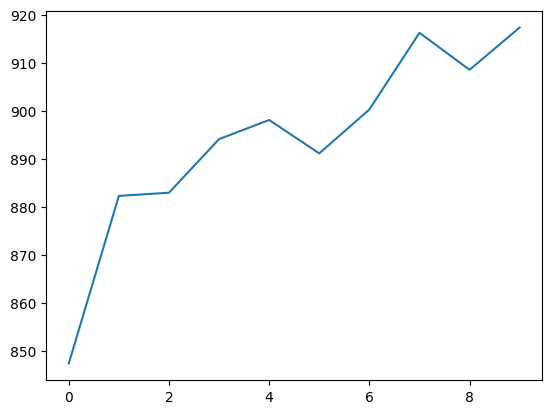

In [67]:
max_test_day_before = 10

day_before_mse_list = []
for prev_day in range(1, max_test_day_before + 1, 1):
    X_train = df_train.drop(columns=["Date"]).shift(1).dropna().reset_index(drop=True)
    if prev_day > 0:
        for i in range(1, prev_day + 1, 1):
            X_train[f"Open-{i}"] = X_train["Open"].shift(i)
            X_train[f"Low-{i}"] = X_train["Low"].shift(i)
            X_train[f"High-{i}"] = X_train["High"].shift(i)
            X_train[f"Close-{i}"] = X_train["Close"].shift(i)
            X_train[f"Volume-{i}"] = X_train["Volume"].shift(i)
    X_train = X_train.dropna().reset_index(drop=True)

    y_train = df_train[["Close"]][prev_day + 1 :].reset_index(drop=True)

    kfold = KFold(n_splits=10)

    mse_list = []
    for train_index, test_index in kfold.split(X_train, y_train):
        X_train_fold, X_validate_fold = (
            X_train.iloc[train_index],
            X_train.iloc[test_index],
        )
        y_train_fold, y_validate_fold = (
            y_train.iloc[train_index],
            y_train.iloc[test_index],
        )

        model = LinearRegression()
        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_validate_fold)
        mse = mean_squared_error(y_validate_fold, y_pred)
        mse_list.append(mse)

    day_before_mse_list.append(sum(mse_list) / len(mse_list))

plt.plot(day_before_mse_list)
plt.show()

In [68]:
max_test_day_before = 10

day_before_mse_list = []

X_train = df_train.drop(columns=["Date"]).shift(1).dropna().reset_index(drop=True)
X_train = X_train.dropna().reset_index(drop=True)
y_train = df_train[["Close"]][1 :].reset_index(drop=True)

X_test = df_test.drop(columns=["Date"]).shift(1).dropna().reset_index(drop=True)
X_test = X_test.dropna().reset_index(drop=True)
y_test = df_test[["Close"]][1 :].reset_index(drop=True)

model = LinearRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

accuracy


0.9225680764145269

## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

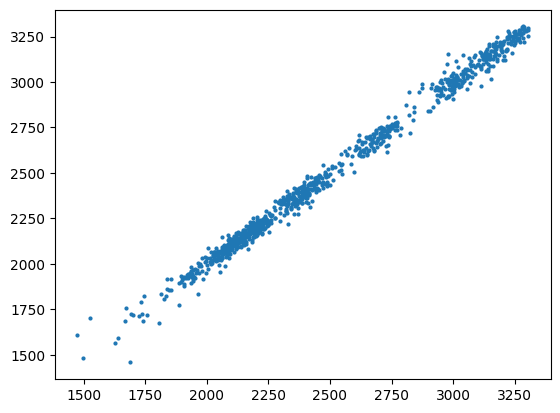

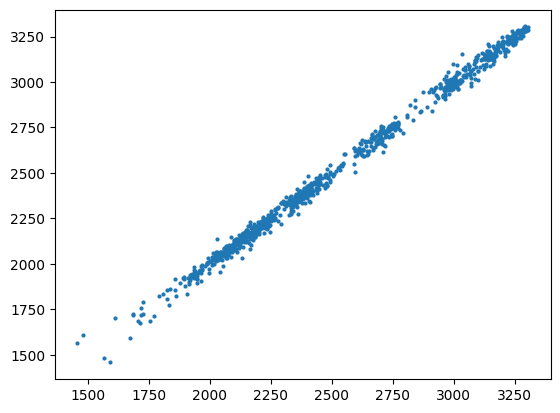

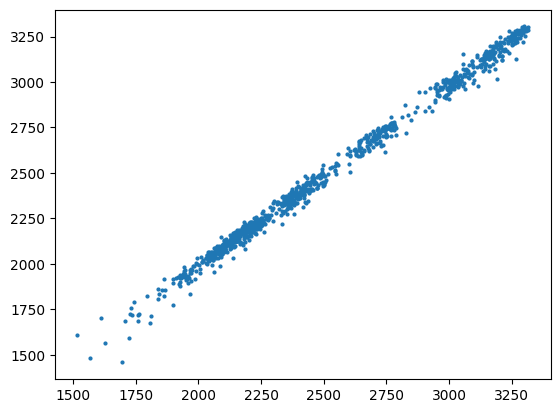

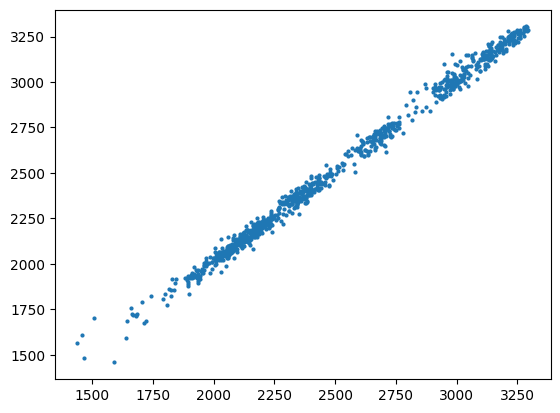

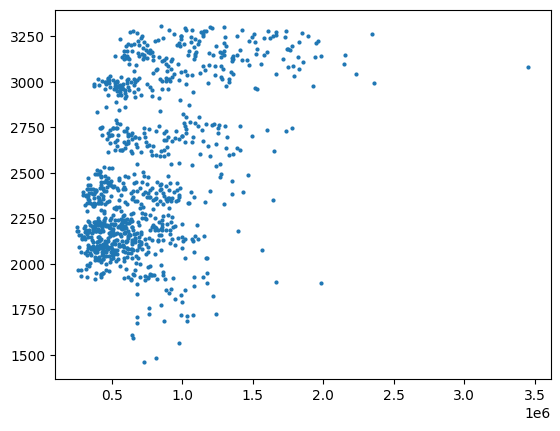

In [69]:

X = df_train[["Open"]].shift(1).dropna().reset_index(drop=True)
y = df_train[["Close"]][1 :].reset_index(drop=True)

plt.scatter(X, y, s=4)
plt.show()

X = df_train[["Close"]].shift(1).dropna().reset_index(drop=True)
y = df_train[["Close"]][1 :].reset_index(drop=True)

plt.scatter(X, y, s=4)
plt.show()

X = df_train[["High"]].shift(1).dropna().reset_index(drop=True)
y = df_train[["Close"]][1 :].reset_index(drop=True)

plt.scatter(X, y, s=4)
plt.show()

X = df_train[["Low"]].shift(1).dropna().reset_index(drop=True)
y = df_train[["Close"]][1 :].reset_index(drop=True)

plt.scatter(X, y, s=4)
plt.show()

X = df_train[["Volume"]].shift(1).dropna().reset_index(drop=True)
y = df_train[["Close"]][1 :].reset_index(drop=True)

plt.scatter(X, y, s=4)
plt.show()







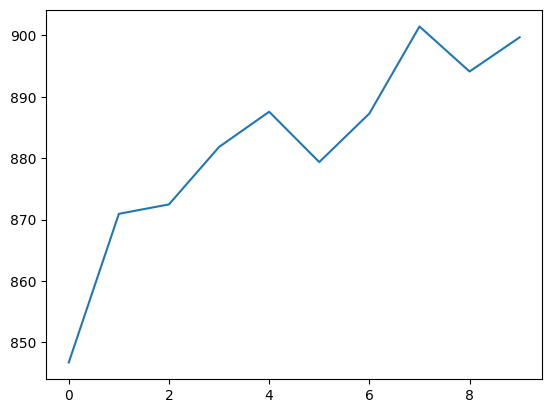

In [70]:
max_test_day_before = 10

day_before_mse_list = []
for prev_day in range(1, max_test_day_before + 1, 1):
    X_train = df_train.drop(columns=["Date"]).shift(1).dropna().reset_index(drop=True)
    if prev_day > 0:
        for i in range(1, prev_day + 1, 1):
            X_train[f"Open-{i}"] = X_train["Open"].shift(i)
            X_train[f"Low-{i}"] = X_train["Low"].shift(i)
            X_train[f"High-{i}"] = X_train["High"].shift(i)
            X_train[f"Close-{i}"] = X_train["Close"].shift(i)
            # X_train[f"Volume-{i}"] = X_train["Volume"].shift(i)
    X_train = X_train.dropna().reset_index(drop=True)

    y_train = df_train[["Close"]][prev_day + 1 :].reset_index(drop=True)

    kfold = KFold(n_splits=10)

    mse_list = []
    for train_index, test_index in kfold.split(X_train, y_train):
        X_train_fold, X_validate_fold = (
            X_train.iloc[train_index],
            X_train.iloc[test_index],
        )
        y_train_fold, y_validate_fold = (
            y_train.iloc[train_index],
            y_train.iloc[test_index],
        )

        model = LinearRegression()
        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_validate_fold)
        mse = mean_squared_error(y_validate_fold, y_pred)
        mse_list.append(mse)

    day_before_mse_list.append(sum(mse_list) / len(mse_list))

plt.plot(day_before_mse_list)
plt.show()

In [71]:
X_train = df_train.drop(columns=["Date", "Volume"]).shift(1).dropna().reset_index(drop=True)
X_train = X_train.dropna().reset_index(drop=True)
y_train = df_train[["Close"]][1 :].reset_index(drop=True)

X_test = df_test.drop(columns=["Date", "Volume"]).shift(1).dropna().reset_index(drop=True)
X_test = X_test.dropna().reset_index(drop=True)
y_test = df_test[["Close"]][1 :].reset_index(drop=True)

model = LinearRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

accuracy


0.9231772610400115